# 🧪 실험 3 (v3): EDA 기반 개선판 — 속도 + 과적합 + 데이터 품질

---

## 📊 v3에서 추가된 점 (v2 → v3)

실제 데이터 EDA에서 발견한 3가지 문제를 추가로 반영했습니다.

| # | 발견한 문제 | v3 개선 | 효과 |
|---|------------|---------|------|
| ① | 16:9 원본을 224 정사각으로 강제 리사이즈 → **가로 1.78배 찌그러짐** | **letterbox 패딩 리사이즈** | 병변 형태 보존 (A4·A6에 특히 유리) |
| ② | `class_weight`가 질환 기준 → 질환은 균형이라 **효과 거의 없음** | **`sample_weight`로 종(반려묘) 기준 가중** | 소수 클래스(반려묘) 성능 실질 향상 |
| ③ | 현미경(CYT) 이미지가 일반카메라(IMG)와 섞임 → 해상도·밝기 분포 상이 | **IMG만 필터링** | 학습 분포 일관성 확보 |

### v2에서 이미 적용된 것 (유지)
- ⚡ 속도: tf.data prefetch, 증강 경량화(rotation 15), batch 32
- 📉 과적합: Dropout 0.5, EarlyStopping patience 3, ReduceLR factor 0.3

> 💾 저장 경로: `exp3_weighted_v3.h5` (v2 결과 보존)

> ⚠️ **EDA 핵심 사실**: 반려묘는 A2·A4·A6·A7 4개 클래스에만 존재하고 **A1·A3·A5에는 0장**입니다. 따라서 종별 성능 비교는 이 4개 클래스에서만 유효합니다.

---

|------|------|------|------|
| 🐢 속도 | 데이터 파이프라인 | ImageDataGenerator | **+ tf.data prefetch** | GPU 유휴 제거 (에폭 20분→5~8분) |
| 🐢 속도 | `rotation_range` | 30 | **15** | CPU 전처리 부하 감소 |
| 🐢 속도 | `BATCH_SIZE` | 64 | **32** | 소수 클래스 등장 빈도↑ |
| 📉 과적합 | `Dropout` | 0.3 | **0.5** | 정확도 하락 직접 차단 |
| 📉 과적합 | `ReduceLROnPlateau factor` | 0.5 | **0.3** | 과적합 구간 LR 빠른 감소 |
| 📉 과적합 | `EarlyStopping patience` | 5 | **3** | 하락 시작 시 즉시 종료 |

> 💡 `LEARNING_RATE`는 **1e-4 그대로 유지**합니다. 정확도가 오르다 떨어지는 건 LR이 낮아서가 아니라 과적합이 원인이므로, LR을 올리면 오히려 악화됩니다.


---

## 이 모델이 하는 일

실험 1, 2와 동일하게 **반려동물 피부 사진 → 7가지 질환 분류**를 수행합니다.

```
📸 반려동물 피부 사진 입력
        ↓
    [EfficientNetB0 + 커스텀 분류층 + 종별 가중치]
        ↓
    A4 농포/여드름 : 92.4%  ← 예측 결과 (반려묘도 잘 맞춤!)
```

## 실험 1, 2와 무엇이 다른가?

| 항목 | 실험 1 | 실험 2 | 실험 3 (이번) |
|------|--------|--------|-------------|
| **모델** | 직접 설계 CNN | EfficientNetB0 | EfficientNetB0 |
| **증강** | ❌ 없음 | ✅ 적용 | ✅ 적용 |
| **Class Weight** | ❌ 없음 | ❌ 없음 | ✅ **적용** |
| **핵심 질문** | 분류 가능한가? | 성능이 올라가는가? | **소수 클래스(반려묘) 성능이 올라가는가?** |

## 왜 Class Weight가 필요한가?

현재 데이터에 **종별 불균형**이 존재합니다:

```
반려견(D): 31,010장 (88.6%) ← 압도적으로 많음
반려묘(C):  3,990장 (11.4%) ← 매우 적음
```

Class Weight 없이 학습하면 모델이 **반려견 데이터에 편향**되어, 반려묘 이미지를 잘 분류하지 못할 수 있습니다.

## Class Weight 동작 원리

```
반려견(D) 가중치: 0.563  → 흔한 데이터니까 loss 기여도를 줄임
반려묘(C) 가중치: 4.443  → 희귀한 데이터니까 loss 기여도를 4.4배 높임
```

모델이 반려묘 이미지를 틀리면 **4.4배 큰 벌점(loss)**을 받으므로, 반려묘도 잘 맞추도록 학습됩니다.

## 기대 효과

- 전체 정확도는 실험 2와 비슷하거나 약간 변동
- **반려묘 클래스의 Recall/F1이 향상** (소수 클래스 성능 개선)
- 더 공정한 모델 → **실제 서비스 배포에 적합한 최종 후보**

---


## 0. 라이브러리 임포트 및 설정

실험 2와 동일합니다. 추가로 **class_weight 계산을 위한 sklearn** 유틸리티를 임포트합니다.


In [14]:
!pip install torch

In [15]:
import sys
print(f"Python: {sys.executable}")

import torch
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA 버전: {torch.version.cuda}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {total_mem:.1f} GB")
    device = torch.device("cuda")
else:
    print("GPU 없음 — CPU로 실행")
    device = torch.device("cpu")

print(f"사용 디바이스: {device}")


Python: d:\anaconda\envs\tf_gpu\python.exe
PyTorch 버전: 2.5.1+cu121
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 2070 SUPER
CUDA 버전: 12.1
VRAM: 8.0 GB
사용 디바이스: cuda


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.models as models
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"PyTorch    : {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"디바이스   : {device}")


PyTorch    : 2.5.1+cu121
torchvision: 0.20.1+cu121
디바이스   : cuda


## 1. 경로 설정 및 데이터 로딩

실험 1, 2와 **동일한 데이터, 동일한 분할**을 사용합니다.  
실험 간 공정한 비교를 위해 데이터는 절대 바꾸지 않습니다.


In [17]:
ROOT      = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
FIG_DIR   = ROOT / 'outputs' / 'figures'
MODEL_DIR = ROOT / 'models'

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# CSV 로딩
df = pd.read_csv(PROCESSED / 'dataset_cleaned.csv')
target_col = 'img_path'

# ── ③ v3 개선: 현미경(CYT) 이미지 제외, 일반카메라(IMG)만 사용 ──
# CYT는 2048x1644·밝기 188로 일반카메라(1920x1080·밝기 135)와 분포가 완전히 다름
# 파일명 접두사로 구분: IMG_* (일반카메라) vs CYT_* (현미경)
before = len(df)
df = df[df['img_file'].str.startswith('IMG')].copy()
removed = before - len(df)
print(f"③ CYT(현미경) 제외: {removed:,}장 제거 → {len(df):,}장 유지\n")

df_train = df[df['split'] == 'train'].copy()
df_val   = df[df['split'] == 'val'].copy()
df_test  = df[df['split'] == 'test'].copy()

print(f"✅ 데이터 로드 완료 (IMG 일반카메라만)")
print(f"  train : {len(df_train):,}장")
print(f"  val   : {len(df_val):,}장")
print(f"  test  : {len(df_test):,}장")

# 종별 분포 확인 (EDA 기반 — 반려묘는 A2/A4/A6/A7에만 존재)
print(f"\n  [종별 분포]")
for sp in ['D', 'C']:
    label = '반려견' if sp == 'D' else '반려묘'
    cnt = len(df_train[df_train['species'] == sp])
    print(f"    {sp}({label}): {cnt:,}장")

③ CYT(현미경) 제외: 0장 제거 → 34,987장 유지

✅ 데이터 로드 완료 (IMG 일반카메라만)
  train : 24,492장
  val   : 5,249장
  test  : 5,246장

  [종별 분포]
    D(반려견): 21,736장
    C(반려묘): 2,756장


## 2. 하이퍼파라미터 설정

실험 2와 동일합니다. Class Weight는 별도 단계에서 계산합니다.


In [18]:
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 15
NUM_CLASSES   = 7
LEARNING_RATE = 0.0001

print(f"이미지 크기  : {IMG_SIZE}")
print(f"배치 크기    : {BATCH_SIZE}")
print(f"최대 에폭    : {EPOCHS}")
print(f"클래스 수    : {NUM_CLASSES}")
print(f"학습률       : {LEARNING_RATE}")


이미지 크기  : (224, 224)
배치 크기    : 32
최대 에폭    : 15
클래스 수    : 7
학습률       : 0.0001


## 3. 가중치 계산 (v3: 종 기준 sample_weight)

> 🔄 **v3 변경**: 아래 표는 원본(v2) 설명입니다. v3에서는 질환 class_weight 대신 **종(species) 기준 sample_weight**를 학습에 사용합니다 (질환은 균형이라 효과가 없었기 때문).

### (원본 설명) Class Weight 계산 ⭐ (실험 3 핵심)

이 단계가 **실험 2와의 유일한 차이점**입니다.

### 실험 3에서 적용하는 가중치

| 가중치 | 기준 | 적용 방식 | 목적 |
|--------|------|----------|------|
| **class_weight** | 질환별 (A1~A7) | `model.fit(class_weight=...)` | 질환 클래스 불균형 보정 ✅ |
| species_weight | 종별 (반려견/반려묘) | 참고용 (학습 미적용) | 불균형 규모 파악 |

> 💡 종별 불균형(`species_weight`)은 데이터 현황 파악을 위해 계산하되, 학습에는 적용하지 않습니다.  
> 종별 불균형까지 보정하려면 `sample_weight`로 결합 가중치를 적용할 수 있으나, 실험 3에서는 질환별 `class_weight`만 사용합니다.

### sample_weight vs class_weight 차이

- `class_weight`: **클래스 단위** 가중치. A1이 적으면 A1 전체에 높은 가중치
- `sample_weight`: **샘플(이미지) 단위** 가중치. 같은 A1이라도 반려묘면 가중치가 더 높음

In [19]:
# ── ② v3 개선: 종(species) 가중치를 sample_weight로 학습에 실제 적용 ──
# EDA 발견: 질환(lesion)은 거의 균형 → lesion 기준 class_weight는 효과 미미
# 진짜 불균형은 종(반려견 88.6% vs 반려묘 11.4%)이므로 종 기준으로 가중

species_classes = np.array(sorted(df_train['species'].unique()))
species_weights = compute_class_weight(
    class_weight='balanced',
    classes=species_classes,
    y=df_train['species']
)
species_weight_map = dict(zip(species_classes, species_weights))  # {'C': ~3.x, 'D': ~0.5x}

print("=== 종별(species) 가중치 (v3: 학습에 실제 적용) ===")
for k, v in species_weight_map.items():
    label = '반려묘' if k == 'C' else '반려견'
    count = len(df_train[df_train['species'] == k])
    print(f"  {k} ({label}): {v:.3f}  (데이터 {count:,}장)")
print("\n  → 이 가중치로 각 샘플의 sample_weight를 만들어 model.fit에 전달합니다.")

=== 종별(species) 가중치 (v3: 학습에 실제 적용) ===
  C (반려묘): 4.443  (데이터 2,756장)
  D (반려견): 0.563  (데이터 21,736장)

  → 이 가중치로 각 샘플의 sample_weight를 만들어 model.fit에 전달합니다.


In [20]:
# ── 3-2. 질환별(lesion) 클래스 가중치 계산 ──
# Generator의 class_indices 순서에 의존하지 않도록 이름→가중치 맵으로 저장
# class_weight_dict는 Generator 생성 후 class_indices를 참조하여 확정 (Section 4)

lesion_classes = sorted(df_train['lesion'].unique())
lesion_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(lesion_classes),
    y=df_train['lesion']
)
lesion_weight_map = dict(zip(lesion_classes, lesion_weights))  # {클래스명: 가중치}

print("=== 질환별(lesion) 클래스 가중치 ===")
for cls, w in lesion_weight_map.items():
    count = len(df_train[df_train['lesion'] == cls])
    print(f"  {cls} → 가중치 {w:.3f}  (데이터 {count:,}장)")

=== 질환별(lesion) 클래스 가중치 ===
  A1 → 가중치 1.000  (데이터 3,499장)
  A2 → 가중치 1.000  (데이터 3,499장)
  A3 → 가중치 1.000  (데이터 3,498장)
  A4 → 가중치 1.001  (데이터 3,497장)
  A5 → 가중치 1.000  (데이터 3,500장)
  A6 → 가중치 1.000  (데이터 3,499장)
  A7 → 가중치 1.000  (데이터 3,500장)


## 4. 데이터 Generator 생성 (증강 적용)

실험 2와 **동일한 증강 설정**입니다.  
Class Weight는 Generator가 아니라 **model.fit()에서 적용**합니다.


In [21]:
# ① LetterboxResize: 16:9 종횡비 보존 (TF resize_with_pad 동일 효과)
class LetterboxResize:
    def __init__(self, size):
        self.size = size  # (H, W)

    def __call__(self, img):
        w, h = img.size
        scale   = min(self.size[0] / h, self.size[1] / w)
        new_h   = int(h * scale)
        new_w   = int(w * scale)
        img     = TF.resize(img, [new_h, new_w])
        pad_t   = (self.size[0] - new_h) // 2
        pad_b   = self.size[0] - new_h - pad_t
        pad_l   = (self.size[1] - new_w) // 2
        pad_r   = self.size[1] - new_w - pad_l
        img     = TF.pad(img, [pad_l, pad_t, pad_r, pad_b], fill=0)
        return img

# EfficientNetB0 사전학습 통계 (ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# PyTorch Dataset
class SkinDataset(Dataset):
    def __init__(self, paths, labels, weights=None, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.weights   = weights
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.weights is not None:
            return img, label, torch.tensor(self.weights[idx], dtype=torch.float32)
        return img, label

print("Dataset / Transforms 정의 완료")
print("  ① LetterboxResize: 16:9 종횡비 보존")
print("  ② ImageNet 정규화 (EfficientNetB0 사전학습 통계)")


Dataset / Transforms 정의 완료
  ① LetterboxResize: 16:9 종횡비 보존
  ② ImageNet 정규화 (EfficientNetB0 사전학습 통계)


In [22]:
lesion_to_idx = {cls: i for i, cls in enumerate(lesion_classes)}
idx_to_lesion = {i: cls for cls, i in lesion_to_idx.items()}
print("클래스 인덱스:", lesion_to_idx)

def df_to_arrays(d, with_weight=False):
    paths   = d[target_col].values
    labels  = np.array([lesion_to_idx[l] for l in d["lesion"].values], dtype=np.int64)
    if with_weight:
        weights = np.array([species_weight_map[s] for s in d["species"].values], dtype=np.float32)
        return paths, labels, weights
    return paths, labels

train_paths, train_labels, train_weights = df_to_arrays(df_train, with_weight=True)
val_paths,   val_labels                  = df_to_arrays(df_val)
test_paths,  test_labels                 = df_to_arrays(df_test)

print(f"\ntrain: {len(train_paths):,} / val: {len(val_paths):,} / test: {len(test_paths):,}")
print(f"  ② 종 sample_weight — 반려묘: {species_weight_map['C']:.3f}, 반려견: {species_weight_map['D']:.3f}")


클래스 인덱스: {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}

train: 24,492 / val: 5,249 / test: 5,246
  ② 종 sample_weight — 반려묘: 4.443, 반려견: 0.563


## 4-1. PyTorch DataLoader 구성

SkinDataset + DataLoader로 파이프라인을 구성합니다:

- **Train**: `(img, label, sample_weight)` 3-튜플, 증강 O
- **Val/Test**: `(img, label)` 2-튜플, 증강 X
- `pin_memory=True`: CPU→GPU 전송 속도 향상
- `num_workers=0`: Windows Jupyter 호환 (필요시 2~4로 늘릴 수 있음)


In [23]:
train_ds = SkinDataset(train_paths, train_labels, weights=train_weights, transform=train_transform)
val_ds   = SkinDataset(val_paths,   val_labels,   transform=eval_transform)
test_ds  = SkinDataset(test_paths,  test_labels,  transform=eval_transform)

# num_workers=0: Windows Jupyter 환경에서 안정적 (spawn 이슈 방지)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print("DataLoader 구성 완료")
print(f"  train: {len(train_ds):,}장, {len(train_loader)}배치")
print(f"  val  : {len(val_ds):,}장,  {len(val_loader)}배치")
print(f"  test : {len(test_ds):,}장,  {len(test_loader)}배치")


DataLoader 구성 완료
  train: 24,492장, 766배치
  val  : 5,249장,  165배치
  test : 5,246장,  164배치


## 5. EfficientNetB0 + 커스텀 분류층 정의 (PyTorch)

```
입력 (224×224×3)
    ↓
EfficientNetB0.features (ImageNet 사전학습, freeze)
    ↓
AdaptiveAvgPool2d → 1280
    ↓
Dropout(0.5) → Linear(1280→256) → ReLU → Dropout(0.5)
    ↓
Linear(256→7) → [A1~A7 로짓]
```


In [24]:
import ssl

# SSL 인증서 검증 비활성화
ssl._create_default_https_context = ssl._create_unverified_context

# 그 다음 기존 코드 실행
from torchvision import models

backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
print("🎉 EfficientNetB0 가중치 다운로드 성공!")

🎉 EfficientNetB0 가중치 다운로드 성공!


In [25]:
# EfficientNetB0 사전학습 가중치 로드
backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# 특징 추출부(features) 동결
for param in backbone.features.parameters():
    param.requires_grad = False

# 분류 헤드 교체 (1280 → 256 → 7)
backbone.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES),
)

model = backbone.to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("EfficientNetB0 모델 구성 완료")
print(f"  전체 파라미터     : {total_p:,}")
print(f"  학습 가능 파라미터 : {trainable_p:,}  (분류 헤드만)")
print(f"  동결된 파라미터    : {total_p - trainable_p:,}")


EfficientNetB0 모델 구성 완료
  전체 파라미터     : 4,337,283
  학습 가능 파라미터 : 329,735  (분류 헤드만)
  동결된 파라미터    : 4,007,548


## 6. 옵티마이저 / 손실함수 / 스케줄러 설정

- **Optimizer**: Adam (학습 가능 파라미터만)
- **Loss**: `CrossEntropyLoss(reduction="none")` → sample_weight를 직접 곱한 뒤 `.mean()`
- **Scheduler**: `ReduceLROnPlateau(factor=0.3, patience=2)`


In [26]:
# 학습 가능 파라미터만 optimizer에 전달
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

# reduction="none": sample_weight를 배치 단위로 곱하기 위해
criterion = nn.CrossEntropyLoss(reduction="none")

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=2, min_lr=1e-7
)

print("학습 설정 완료")
print(f"  Optimizer : Adam(lr={LEARNING_RATE})")
print(f"  Loss      : CrossEntropyLoss (reduction=none, sample_weight 적용)")
print(f"  Scheduler : ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-7)")


학습 설정 완료
  Optimizer : Adam(lr=0.0001)
  Loss      : CrossEntropyLoss (reduction=none, sample_weight 적용)
  Scheduler : ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-7)


## 7. 학습 설정 (EarlyStopping / ModelCheckpoint)

TF Callback 대신 학습 루프 안에서 직접 구현합니다.

| 기능 | 설정 |
|------|------|
| EarlyStopping | patience=3, val_loss 기준 |
| ModelCheckpoint | val_loss 최저 시 `.pt` 저장 |
| ReduceLROnPlateau | 이미 scheduler에 설정됨 |


In [27]:
save_path       = MODEL_DIR / "exp3_weighted_v3.pt"
best_val_loss   = float("inf")
patience_counter = 0
PATIENCE        = 3
history = {"loss": [], "acc": [], "val_loss": [], "val_acc": [], "lr": []}

print(f"모델 저장 경로 : {save_path}")
print(f"EarlyStopping  : patience={PATIENCE}")


모델 저장 경로 : ..\models\exp3_weighted_v3.pt
EarlyStopping  : patience=3


## 8. 모델 학습 (PyTorch 학습 루프)

train_loader가 `(img, label, sample_weight)` 3-튜플을 반환하므로,
loss를 sample_weight로 가중 평균합니다:

```python
loss_per_sample = criterion(outputs, labels)   # (N,)
loss = (loss_per_sample * sample_weights).mean()
```


In [28]:
def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = total_correct = total_samples = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            if len(batch) == 3:
                imgs, labels, sample_w = batch
                sample_w = sample_w.to(device)
            else:
                imgs, labels = batch[0], batch[1]
                sample_w = None

            imgs   = imgs.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs          = model(imgs)
            loss_per_sample  = criterion(outputs, labels)          # (N,)
            loss = (loss_per_sample * sample_w).mean() if sample_w is not None                    else loss_per_sample.mean()

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss    += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += imgs.size(0)

    return total_loss / total_samples, total_correct / total_samples


print("=" * 55)
print("실험 3 (v3 PyTorch + GPU): 학습 시작")
print("=" * 55)
print(f"[v3 적용 요약]")
print(f"  ① LetterboxResize — 16:9 종횡비 보존")
print(f"  ② 종 sample_weight — 반려묘 {species_weight_map['C']:.2f} / 반려견 {species_weight_map['D']:.2f}")
print(f"  ③ CYT 현미경 제외 (IMG만)")
print()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, is_train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   is_train=False)

    current_lr = optimizer.param_groups[0]["lr"]
    history["loss"].append(train_loss)
    history["acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"loss={train_loss:.4f}  acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
          f"lr={current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), save_path)
        print(f"  -> 최적 모델 저장 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  -> 개선 없음 ({patience_counter}/{PATIENCE})")

    scheduler.step(val_loss)

    if patience_counter >= PATIENCE:
        print(f"\nEarlyStopping: {PATIENCE}에폭 개선 없어 학습 중단")
        break

# 최적 가중치 복원
model.load_state_dict(torch.load(save_path, weights_only=True, map_location=device))
print(f"\n학습 완료! (총 {epoch}에폭, best val_loss={best_val_loss:.4f})")
print(f"저장 경로: {save_path}")


실험 3 (v3 PyTorch + GPU): 학습 시작
[v3 적용 요약]
  ① LetterboxResize — 16:9 종횡비 보존
  ② 종 sample_weight — 반려묘 4.44 / 반려견 0.56
  ③ CYT 현미경 제외 (IMG만)

Epoch  1/15  loss=1.8071  acc=0.1673  val_loss=1.9032  val_acc=0.2202  lr=1.00e-04
  -> 최적 모델 저장 (val_loss=1.9032)
Epoch  2/15  loss=1.6950  acc=0.2079  val_loss=1.8532  val_acc=0.2555  lr=1.00e-04
  -> 최적 모델 저장 (val_loss=1.8532)
Epoch  3/15  loss=1.6525  acc=0.2212  val_loss=1.8330  val_acc=0.2644  lr=1.00e-04
  -> 최적 모델 저장 (val_loss=1.8330)
Epoch  4/15  loss=1.6303  acc=0.2323  val_loss=1.8206  val_acc=0.2745  lr=1.00e-04
  -> 최적 모델 저장 (val_loss=1.8206)
Epoch  5/15  loss=1.6150  acc=0.2407  val_loss=1.8090  val_acc=0.2795  lr=1.00e-04
  -> 최적 모델 저장 (val_loss=1.8090)
Epoch  6/15  loss=1.5957  acc=0.2446  val_loss=1.7961  val_acc=0.2865  lr=1.00e-04
  -> 최적 모델 저장 (val_loss=1.7961)
Epoch  7/15  loss=1.5791  acc=0.2489  val_loss=1.7951  val_acc=0.2858  lr=1.00e-04
  -> 최적 모델 저장 (val_loss=1.7951)
Epoch  8/15  loss=1.5690  acc=0.2586  val_loss=1.7787 

## 9. 학습 곡선 시각화

실험 2와 비교하여 **Val Loss/Accuracy가 어떻게 달라졌는지** 확인합니다.


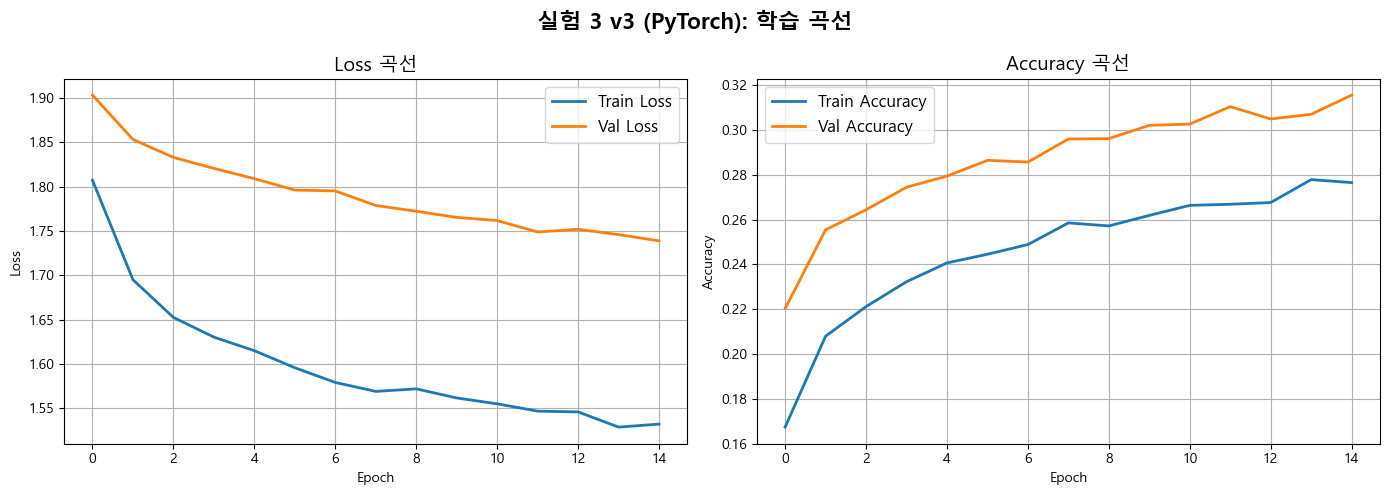

학습 곡선 저장 -> ..\outputs\figures\exp3_v3_learning_curve.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["loss"],     label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss",   linewidth=2)
axes[0].set_title("Loss 곡선", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=12); axes[0].grid(True)

axes[1].plot(history["acc"],     label="Train Accuracy", linewidth=2)
axes[1].plot(history["val_acc"], label="Val Accuracy",   linewidth=2)
axes[1].set_title("Accuracy 곡선", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=12); axes[1].grid(True)

plt.suptitle("실험 3 v3 (PyTorch): 학습 곡선", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "exp3_v3_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"학습 곡선 저장 -> {FIG_DIR / 'exp3_v3_learning_curve.png'}")


## 10. 테스트 데이터 평가


In [30]:
print("=" * 50)
print("테스트 데이터 평가")
print("=" * 50)

model.eval()
total_loss_sum = total_correct = total_samples = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels).mean()
        total_loss_sum += loss.item() * imgs.size(0)
        total_correct  += (outputs.argmax(1) == labels).sum().item()
        total_samples  += imgs.size(0)

test_loss = total_loss_sum / total_samples
test_acc  = total_correct  / total_samples

print(f"\n테스트 Loss    : {test_loss:.4f}")
print(f"테스트 Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")


테스트 데이터 평가

테스트 Loss    : 1.7427
테스트 Accuracy: 0.3176 (31.8%)


## 11. 상세 평가 — Classification Report

실험 2 대비 **반려묘 관련 클래스의 Recall/F1이 올랐는지** 확인하는 것이 핵심입니다.


In [31]:
model.eval()
all_preds, all_labels_list = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels_list.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels_list)

class_names = [idx_to_lesion[i] for i in range(NUM_CLASSES)]
LESION_MAP = {
    "A1": "A1 구진/플라크", "A2": "A2 비듬/각질", "A3": "A3 태선화/색소",
    "A4": "A4 농포/여드름", "A5": "A5 미란/궤양", "A6": "A6 결절/종괴",
    "A7": "A7 무증상(정상)"
}
class_labels = [LESION_MAP[c] for c in class_names]

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))


=== Classification Report ===
              precision    recall  f1-score   support

   A1 구진/플라크       0.28      0.32      0.30       749
    A2 비듬/각질       0.31      0.28      0.29       750
   A3 태선화/색소       0.29      0.38      0.33       750
   A4 농포/여드름       0.26      0.20      0.23       749
    A5 미란/궤양       0.45      0.22      0.29       750
    A6 결절/종괴       0.34      0.44      0.39       750
  A7 무증상(정상)       0.36      0.38      0.37       748

    accuracy                           0.32      5246
   macro avg       0.33      0.32      0.31      5246
weighted avg       0.33      0.32      0.31      5246



### 11-1. Confusion Matrix (혼동 행렬)

실험 2 대비 **대각선 값이 더 고르게 분포**하는지 확인하세요.  
특정 클래스만 잘 맞추는 게 아니라, 모든 클래스를 공평하게 맞추는 것이 목표입니다.


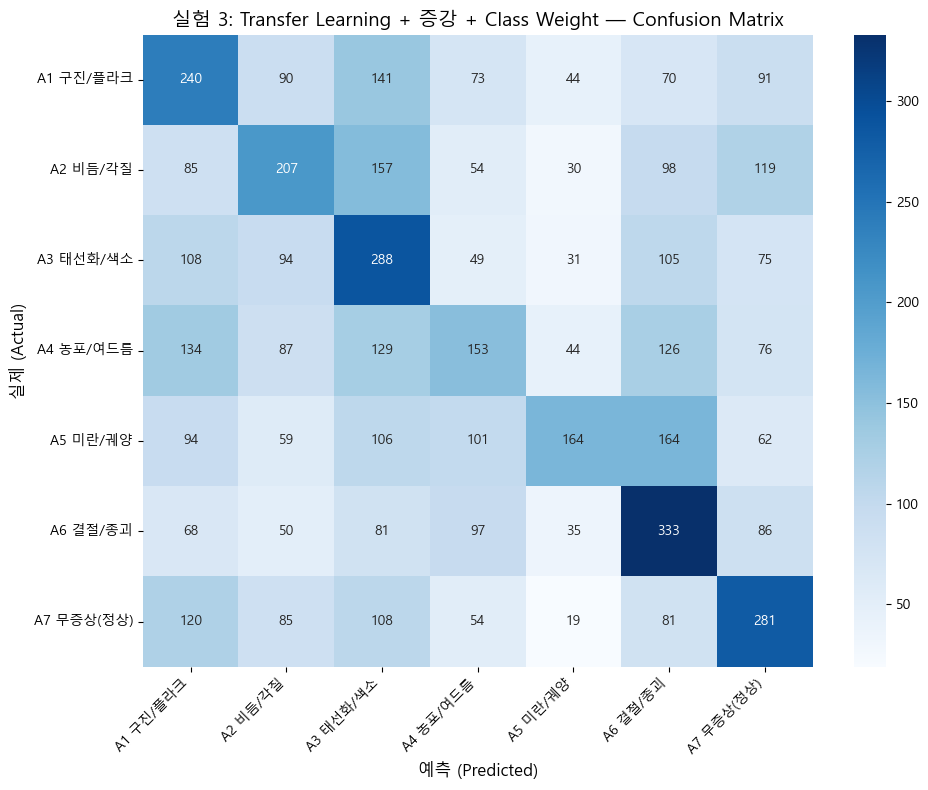

📊 혼동 행렬 저장 → ..\outputs\figures\exp3_confusion_matrix.png


In [32]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('예측 (Predicted)', fontsize=12)
ax.set_ylabel('실제 (Actual)', fontsize=12)
ax.set_title('실험 3: Transfer Learning + 증강 + Class Weight — Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(FIG_DIR / 'exp3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 혼동 행렬 저장 → {FIG_DIR / 'exp3_confusion_matrix.png'}")


## 12. 종별(반려견/반려묘) 성능 분석 ⭐ (실험 3 전용)

Class Weight의 효과를 확인하기 위해, **반려견과 반려묘 각각의 정확도**를 측정합니다.  
실험 2 대비 **반려묘 정확도가 올랐는지**가 핵심 비교 포인트입니다.


In [33]:
# test_loader는 shuffle=False이므로 df_test 순서 == y_pred 순서
test_species = df_test["species"].values

dog_mask = (test_species == "D")
cat_mask = (test_species == "C")
dog_acc  = np.mean(y_pred[dog_mask] == y_true[dog_mask])
cat_acc  = np.mean(y_pred[cat_mask] == y_true[cat_mask]) if cat_mask.sum() > 0 else float("nan")

print("=" * 50)
print("종별 정확도 분석 (v3)")
print("=" * 50)
print(f"  반려견(D) 정확도: {dog_acc:.4f} ({dog_acc*100:.1f}%) — {dog_mask.sum():,}장")
print(f"  반려묘(C) 정확도: {cat_acc:.4f} ({cat_acc*100:.1f}%) — {cat_mask.sum():,}장")
print(f"  전체     정확도: {test_acc:.4f} ({test_acc*100:.1f}%)")
print()
print("  반려묘는 A2/A4/A6/A7 4개 클래스만 존재 (A1/A3/A5는 0장)")


종별 정확도 분석 (v3)
  반려견(D) 정확도: 0.2811 (28.1%) — 4,621장
  반려묘(C) 정확도: 0.5872 (58.7%) — 625장
  전체     정확도: 0.3176 (31.8%)

  반려묘는 A2/A4/A6/A7 4개 클래스만 존재 (A1/A3/A5는 0장)


## 13. 실험 3 결과 요약


In [34]:
print("=" * 60)
print("실험 3 v3 (PyTorch + GPU) 결과 요약")
print("=" * 60)
print(f"프레임워크      : PyTorch {torch.__version__} / {device}")
print(f"모델 구조       : EfficientNetB0 (freeze) + Dense 분류 헤드")
print(f"데이터 증강     : LetterboxResize + HFlip + ColorJitter")
print(f"sample_weight   : 종(species) 기준 — 반려묘 {species_weight_map['C']:.3f}")
print(f"학습률          : {LEARNING_RATE}")
print(f"학습 에폭       : {len(history['loss'])}회")
print(f"최종 Train Loss : {history['loss'][-1]:.4f}")
print(f"최종 Train Acc  : {history['acc'][-1]:.4f}")
print(f"최종 Val Loss   : {history['val_loss'][-1]:.4f}")
print(f"최종 Val Acc    : {history['val_acc'][-1]:.4f}")
print(f"테스트 Loss     : {test_loss:.4f}")
print(f"테스트 Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"반려견 정확도   : {dog_acc:.4f} ({dog_acc*100:.1f}%)")
print(f"반려묘 정확도   : {cat_acc:.4f} ({cat_acc*100:.1f}%)")
print(f"모델 저장 경로  : {save_path}")
print("=" * 60)


실험 3 v3 (PyTorch + GPU) 결과 요약
프레임워크      : PyTorch 2.5.1+cu121 / cuda
모델 구조       : EfficientNetB0 (freeze) + Dense 분류 헤드
데이터 증강     : LetterboxResize + HFlip + ColorJitter
sample_weight   : 종(species) 기준 — 반려묘 4.443
학습률          : 0.0001
학습 에폭       : 15회
최종 Train Loss : 1.5322
최종 Train Acc  : 0.2766
최종 Val Loss   : 1.7388
최종 Val Acc    : 0.3157
테스트 Loss     : 1.7427
테스트 Accuracy : 0.3176 (31.8%)
반려견 정확도   : 0.2811 (28.1%)
반려묘 정확도   : 0.5872 (58.7%)
모델 저장 경로  : ..\models\exp3_weighted_v3.pt
